# 🌊 Analisi di onde e maree per la stima del runup costiero

Benvenuti a questa esercitazione pratica dedicata all'**analisi di onde e maree**!
In questo notebook impareremo a usare **Python** per studiare come le onde interagiscono con la costa e come stimare l'altezza massima raggiunta dal moto ondoso sulla spiaggia — il cosiddetto *wave runup*, per un evento di mareggiata reale a vostra scelta.

Durante l'attività vedremo come:

1. 📍 **Definire un sito di studio** (una "boa virtuale") e scaricare una lunga serie storica di dati d'onda da Copernicus Marine Service.
2. 🔎 **Esplorare la serie in modo interattivo** per individuare una mareggiata da modellizzare.
3. 📂 **Scaricare i dati di livello del mare** per l'evento scelto (Rete Mareografica Nazionale — [mareografico.it](https://www.mareografico.it)) e organizzare tutto nella cartella `dati/`.
4. 📈 **Visualizzare** le serie temporali di onde e livelli di marea per l'evento.
5. 🌊 **Stimare il runup costiero** con diversi modelli empirici (pacchetto `py-wave-runup`).
6. 🗺️ **Scegliere i valori di runup** da riportare in QGIS, ai fini della mappatura dell'inondazione costiera.

---

🧠 **Obiettivo didattico**
Questo notebook è pensato per studenti di **Scienze Ambientali o Scienze della Terra**, anche senza precedenti esperienze di programmazione.
Troverai molti commenti e spiegazioni passo passo: il nostro obiettivo è **imparare facendo** (*learn by doing*).

💡 **Suggerimento:**
Puoi modificare il codice e rieseguirlo (⇧ + ⏎) per vedere cosa succede.
Usa le celle di testo (*Markdown*) per prendere appunti e descrivere i risultati delle tue analisi.

## 📂 Accesso ai dati su Google Drive

In questo passaggio impariamo a **collegare il nostro Google Drive** a Colab, così da poter lavorare direttamente con i file salvati nel nostro spazio personale.

Faremo tre operazioni principali:

1. 🔗 **Montare Google Drive** — in modo che Colab possa leggere e scrivere file nelle tue cartelle.
2. 📁 **Impostare la cartella di lavoro** — con due sottocartelle: `dati/` (dove verranno salvati i file scaricati) e `Risultati/` (dove il notebook salverà grafici e tabelle).
3. 🧩 *(Facoltativo)* **Aggiungere una cartella al "Python path"** — così possiamo importare funzioni direttamente da file `.py` scaricati, ad esempio il modello di *wave runup*.

---

> 🔁 **Importante:**
> Se è **la prima volta** che esegui questo notebook, dovrai **decommentare** la riga che inizia con `!git clone` per scaricare il modello *wave runup* da GitHub.
> Questa operazione va fatta **una sola volta** — in seguito la cartella sarà già presente nel tuo Drive.

💡 **Suggerimento per chi usa Colab:**
Quando esegui la cella di montaggio di Drive, Colab ti chiederà di autorizzare l'accesso.

In [2]:
# --- 🔧 Collegamento a Google Drive e impostazione della cartella di lavoro ---
from google.colab import drive
import os
import sys

# 🔗 Monta Google Drive (ti verrà chiesto di autorizzare l'accesso)
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 📁 Imposta la cartella di lavoro principale
# 👉 Modifica il percorso se hai salvato il progetto in una posizione diversa
working_dir = '/content/drive/MyDrive/Wave_Runup'

# 🔄 Spostati nella cartella di lavoro
%cd $working_dir

# Percorso della sottocartella "dati" (dove verranno salvati i file scaricati) e "Risultati" (output del notebook)
dati_dir = os.path.join(working_dir, "dati")
results_dir = os.path.join(working_dir, "Risultati")
os.makedirs(dati_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# 🧩 (Facoltativo) Clona il repository GitHub se non è già presente
# Rimuovi il simbolo "#" dalla riga qui sotto e riesegui la cella solo la prima volta
!git clone https://github.com/chrisleaman/py-wave-runup.git

# ➕ Aggiunge la cartella contenente models.py al percorso di Python
# In questo modo potremo importare le funzioni del modello wave runup
models_path = os.path.join(working_dir, 'py-wave-runup')
sys.path.append(models_path)

/content/drive/MyDrive/Wave_Runup
Cloning into 'py-wave-runup'...
remote: Enumerating objects: 1217, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 1217 (delta 98), reused 143 (delta 66), pack-reused 1011 (from 1)
Receiving objects: 100% (1217/1217), 2.99 MiB | 10.53 MiB/s, done.
Resolving deltas: 100% (724/724), done.


## 🧰 Importazione delle librerie

Prima di iniziare a lavorare con i dati, dobbiamo **importare alcune librerie di Python**.
Le librerie sono "scatole di strumenti" che contengono funzioni già pronte per svolgere operazioni specifiche, come leggere dati, creare grafici o fare calcoli.

In questa esercitazione useremo:

- 📊 **`pandas`** — per caricare, esplorare e manipolare dati.
- 📈 **`matplotlib`** — per creare grafici statici.
- 🖱️ **`plotly`** — per creare grafici **interattivi** (zoom, hover), utili per esplorare la serie storica di onde e scegliere l'evento da modellizzare.
- ➕ **`numpy`** — per lavorare con numeri, array e operazioni matematiche.
- 🌍 **`xarray`** — per leggere i file NetCDF scaricati da Copernicus Marine.
- 🌊 **`py_wave_runup`** — per stimare il *wave runup* usando modelli fisici già implementati.

La libreria **`copernicusmarine`** (per scaricare i dati di moto ondoso) verrà installata più avanti, nella sezione dedicata, così da non appesantire questa cella iniziale.

---

💡 **Suggerimento:**
In Colab o Jupyter puoi eseguire una cella di codice con **Shift + Invio (⇧ + ⏎)**.
Se tutto è installato correttamente, non dovrebbero comparire messaggi di errore dopo l'importazione.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import xarray as xr
from py_wave_runup import models
import os
import datetime

## 📍 Definizione del sito di studio (boa virtuale)

Per individuare una mareggiata da modellizzare dobbiamo prima **guardare una serie storica di dati d'onda** nel punto di mare al largo del vostro sito di studio: una sorta di **boa virtuale**, i cui dati provengono dal modello Copernicus Marine (non da uno strumento reale in acqua).

Nella cella seguente definite:

- **`lat`**, **`lon`** → coordinate geografiche (gradi decimali) del punto al largo del vostro tratto di costa.
- **`explore_start`**, **`explore_end`** → l'intervallo temporale **ampio** da esplorare (es. alcuni mesi o un anno), entro cui cercare una mareggiata significativa. Più è ampio l'intervallo, più mareggiate potrete confrontare — ma il download sarà più lento.

> 💡 Le coordinate esatte non sono critiche: Copernicus Marine userà comunque il punto di griglia del modello più vicino a quello richiesto (risoluzione del modello ≈ 4 km).

> 📅 **Copertura temporale:** per default il notebook usa il prodotto di **rianalisi** Copernicus Marine, che copre dal **1° gennaio 1985 fino a circa un mese prima di oggi** — quindi va benissimo sia per mareggiate storiche sia per la maggior parte degli eventi recenti. Solo se vi serve un evento **degli ultimissimi giorni/settimane** (troppo recente per la rianalisi) dovrete passare al prodotto "analysis-forecast" (istruzioni nella cella di download, più avanti).

In [5]:
# --- 📍 Coordinate del sito di studio e intervallo temporale da esplorare ---

lat = 44.102202   # TODO: latitudine del punto al largo del sito di studio (gradi decimali)
lon = 8.282117   # TODO: longitudine del punto al largo del sito di studio (gradi decimali)

explore_start = "1985-01-01"   # TODO: inizio del periodo da esplorare
explore_end   = "2026-06-30"   # TODO: fine del periodo da esplorare

print(f"📍 Sito di studio: lat={lat}, lon={lon}")
print(f"🕒 Periodo da esplorare: {explore_start} → {explore_end}")

📍 Sito di studio: lat=44.102202, lon=8.282117
🕒 Periodo da esplorare: 1985-01-01 → 2026-06-30


## 🌊📡 Download di una serie storica di onde — Copernicus Marine Service

Scarichiamo ora, per il punto e il periodo definiti sopra, una serie storica **oraria** di:

- **`VHM0`** → altezza significativa dell'onda (Hs, in metri)
- **`VTPK`** → periodo di picco dello spettro d'onda (Tp, in secondi)
- **`VMDR`** → direzione media di provenienza delle onde (in gradi Nord)

dal prodotto **Mediterranean Sea Waves Reanalysis** (`MEDSEA_MULTIYEAR_WAV_006_012`) del Copernicus Marine Service, che copre dal 1985 a circa un mese prima di oggi — la scelta migliore per la maggior parte degli eventi, storici o recenti.

### 🔑 Istruzioni
1. Crea un account gratuito su [Copernicus Marine Service](https://data.marine.copernicus.eu/) (se non ne hai già uno).
2. Esegui la cella di installazione/login qui sotto: la prima volta ti verranno chieste username e password, che verranno salvate localmente per le esecuzioni successive.
3. Esegui la cella di download: scaricherà automaticamente i dati per `explore_start` → `explore_end` nel punto (`lat`, `lon`), e salverà il file NetCDF in `dati/`.

> ⚡ Se invece vi serve un evento **troppo recente per la rianalisi** (ultimi giorni/settimane), sostituite `dataset_id` con il prodotto **"analysis-forecast"** `MEDSEA_ANALYSISFORECAST_WAV_006_017` (istruzioni nel commento del codice: copre gli ultimi anni fino ad oggi + 10 giorni di previsione).

In [6]:
# --- 📦 Installazione del Copernicus Marine Toolbox (una tantum per sessione Colab) ---
!pip install -q copernicusmarine

import copernicusmarine

# 🔑 Login (richiesto solo alla prima esecuzione nella sessione/ambiente)
copernicusmarine.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


INFO - 2026-07-21T15:33:04Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: arovere
Copernicus Marine password: ··········


INFO - 2026-07-21T15:33:08Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


True

In [7]:
# --- 🌊📡 Download della serie storica di onde nel punto della boa virtuale ---

# Prodotto di rianalisi (default): copre dal 1985-01-01 a circa un mese prima di oggi.
dataset_id = "cmems_mod_med_wav_my_4.2km_PT1H-i"   # MEDSEA_MULTIYEAR_WAV_006_012 (rianalisi)

# Se il vostro evento è troppo recente per la rianalisi (ultimi giorni/settimane),
# commentate la riga sopra e decommentate questa (copre gli ultimi anni + 10 giorni di previsione):
# dataset_id = "cmems_mod_med_wav_anfc_4.2km_PT1H-i"   # MEDSEA_ANALYSISFORECAST_WAV_006_017

# Piccolo margine (in gradi) attorno al punto di interesse, per essere sicuri
# di catturare almeno un punto di griglia anche in caso di lieve imprecisione delle coordinate
buffer_deg = 0.08

wave_timeseries_path = os.path.join(dati_dir, "boa_virtuale_wave_timeseries.nc")

copernicusmarine.subset(
    dataset_id=dataset_id,
    variables=["VHM0", "VTPK", "VMDR"],
    minimum_longitude=lon - buffer_deg,
    maximum_longitude=lon + buffer_deg,
    minimum_latitude=lat - buffer_deg,
    maximum_latitude=lat + buffer_deg,
    start_datetime=explore_start,
    end_datetime=explore_end,
    output_filename=wave_timeseries_path,
    force_download=True,
)

print(f"✅ File scaricato in: {wave_timeseries_path}")

WARNING - 2026-07-21T15:33:19Z - 'force_download' has been deprecated.
INFO - 2026-07-21T15:33:22Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-21T15:33:22Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
INFO - 2026-07-21T15:33:30Z - Total size of the download: 25.00 MB.
INFO:copernicusmarine:Total size of the download: 25.00 MB.


✅ File scaricato in: /content/drive/MyDrive/Wave_Runup/dati/boa_virtuale_wave_timeseries.nc


In [8]:
# --- 📖 Lettura del file NetCDF e conversione in DataFrame ---

ds = xr.open_dataset(wave_timeseries_path)

# Selezioniamo il punto di griglia più vicino alle coordinate del sito
point = ds.sel(longitude=lon, latitude=lat, method="nearest")

waves_full_df = point[["VHM0", "VTPK", "VMDR"]].to_dataframe().reset_index()
waves_full_df = waves_full_df.rename(columns={
    "time": "Datetime", "VHM0": "Hs", "VTPK": "Tmean", "VMDR": "Dir"
})
waves_full_df = waves_full_df[["Datetime", "Hs", "Tmean", "Dir"]]

for col in ["Hs", "Tmean", "Dir"]:
    waves_full_df[col] = pd.to_numeric(waves_full_df[col], errors='coerce')

waves_full_df = waves_full_df.dropna(subset=["Hs", "Tmean"]).sort_values("Datetime")
waves_full_df = waves_full_df.set_index("Datetime")

print(f"✅ Serie storica caricata: {len(waves_full_df)} righe orarie")

✅ Serie storica caricata: 363721 righe orarie


## 🔎 Esplorazione interattiva: scegliete la vostra mareggiata

Il grafico qui sotto è **interattivo**: potete fare *zoom* trascinando il mouse sull'area del grafico o sulla barra sotto l'asse del tempo (*range slider*), e passare il mouse sui punti (*hover*) per leggere data, ora e valore esatti.

### 🧭 Come usarlo
1. Osservate l'intera serie e individuate uno o più **picchi di altezza d'onda (Hs)** — le mareggiate più marcate.
2. Fate zoom su un picco che vi interessa: controllate anche come si comportano il **periodo (Tp)** e la **direzione (Dir)** durante l'evento.
3. Individuate il **momento di inizio e fine** della mareggiata (da quando Hs comincia a salire sensibilmente a quando torna a valori di "mare calmo"), aggiungendo un margine di qualche ora/giorno.
4. Annotate queste due date e orari: vi serviranno nella prossima sezione per definire `event_start` ed `event_end`.

> 💡 Come punto di partenza, la cella seguente stampa automaticamente il valore massimo di Hs nella serie esplorata e la data in cui è stato registrato — ma **non dovete necessariamente scegliere quell'evento**: potete selezionare qualunque mareggiata rilevante nella serie, anche in base a informazioni esterne (bollettini meteomarini, cronaca locale, allerte della Protezione Civile).

> ⚡ **Nota sulla fluidità:** se l'intervallo esplorato è lungo (mesi/anni di dati orari), il grafico può diventare lento da usare. Per questo motivo la visualizzazione qui sotto usa un **campionamento adattivo** dei punti (solo a scopo grafico): i dati orari completi restano comunque intatti in `waves_full_df` e vengono usati senza alcuna perdita quando, nella sezione successiva, ritagliate l'evento scelto.

In [9]:
# --- 🖱️ Grafico interattivo: Hs, Tp e direzione nel tempo ---

# Per mantenere il grafico fluido anche con serie lunghe (mesi/anni di dati orari),
# visualizziamo al massimo circa "target_points" punti, campionando la serie a intervalli regolari.
# Questo NON modifica waves_full_df: serve solo per disegnare il grafico più velocemente.
target_points = 10000
step = max(1, len(waves_full_df) // target_points)
waves_plot_df = waves_full_df.iloc[::step]

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    specs=[[{"secondary_y": True}], [{"secondary_y": False}]],
    subplot_titles=("Altezza d'onda (Hs) e periodo di picco (Tp)", "Direzione media di provenienza delle onde")
)

# go.Scattergl (invece di go.Scatter) usa il rendering WebGL, molto più veloce con molti punti
fig.add_trace(
    go.Scattergl(x=waves_plot_df.index, y=waves_plot_df["Hs"], name="Hs [m]", line=dict(color="royalblue")),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scattergl(x=waves_plot_df.index, y=waves_plot_df["Tmean"], name="Tp [s]", line=dict(color="gray")),
    row=1, col=1, secondary_y=True
)
fig.add_trace(
    go.Scattergl(x=waves_plot_df.index, y=waves_plot_df["Dir"], name="Dir [°N]", mode="markers",
               marker=dict(size=3, color="orange")),
    row=2, col=1
)

fig.update_yaxes(title_text="Hs [m]", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Tp [s]", row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text="Direzione [°N]", row=2, col=1, range=[0, 360])
fig.update_xaxes(rangeslider_visible=True, row=2, col=1)
fig.update_layout(
    height=650,
    title=f"Serie storica di moto ondoso — boa virtuale (lat={lat}, lon={lon})",
    hovermode="x"
)

fig.show()

if step > 1:
    print(f"ℹ️ Grafico campionato ogni {step} punti (1 ogni {step} ore) per mantenerlo fluido. Dati orari completi comunque disponibili in waves_full_df.")

# 💡 Suggerimento automatico: valore massimo di Hs nella serie esplorata (calcolato sui dati orari completi)
peak_time = waves_full_df["Hs"].idxmax()
peak_value = waves_full_df["Hs"].max()
print(f"📈 Il valore massimo di Hs nella serie esplorata è {peak_value:.2f} m, registrato il {peak_time}.")
print("   (Potete usare questo evento, oppure sceglierne un altro dal grafico qui sopra.)")

ℹ️ Grafico campionato ogni 36 punti (1 ogni 36 ore) per mantenerlo fluido. Dati orari completi comunque disponibili in waves_full_df.
📈 Il valore massimo di Hs nella serie esplorata è 4.13 m, registrato il 2017-12-11 20:00:00.
   (Potete usare questo evento, oppure sceglierne un altro dal grafico qui sopra.)


## 🌊 Definizione dell'evento di mareggiata

Ora che avete individuato la mareggiata da modellizzare, definite qui i parametri dell'evento:

- **`event_name`** → un nome breve, usato per etichettare i file di output (es. `"mareggiata_maggio2026"`).
- **`event_start`**, **`event_end`** → l'intervallo temporale dell'evento, individuato esplorando il grafico interattivo qui sopra (con un margine di qualche ora/giorno prima e dopo il picco).
- **`station_name`** → il nome della stazione mareografica più vicina al vostro sito (la individuerete nella prossima sezione, su mareografico.it).

Le coordinate del sito (`lat`, `lon`) sono già definite nella sezione "Definizione del sito di studio" e verranno riutilizzate.

In [13]:
# --- 🌊 Parametri dell'evento di mareggiata scelto ---

event_name  = "Maggio"          # TODO: es. "mareggiata_maggio2026"
event_start = "2026-05-09 00:00"     # TODO: inizio dell'evento (dal grafico interattivo, con margine)
event_end   = "2026-05-14 00:00"     # TODO: fine dell'evento (dal grafico interattivo, con margine)

station_name = "NOME_STAZIONE_MAREOGRAFICA"   # TODO: stazione mareografico.it più vicina al sito

print(f"▶️ Evento: {event_name}")
print(f"   Periodo: {event_start} → {event_end}")
print(f"   Stazione di riferimento: {station_name}")

▶️ Evento: Maggio
   Periodo: 2026-05-09 00:00 → 2026-05-14 00:00
   Stazione di riferimento: NOME_STAZIONE_MAREOGRAFICA


✅ Dati di onde selezionati per l'evento 'Maggio': 121 righe


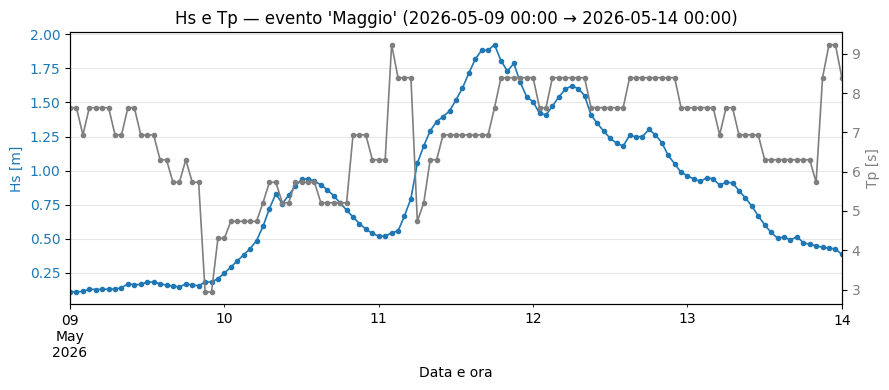

In [14]:
# --- ✂️📈 Ritaglio della serie d'onda sulla finestra dell'evento + verifica grafica ---
# (non serve un nuovo download: usiamo la serie storica scaricata in precedenza)

waves_df = waves_full_df.loc[event_start:event_end].copy()
print(f"✅ Dati di onde selezionati per l'evento '{event_name}': {len(waves_df)} righe")

# 📈 Grafico di Hs e Tp sulla finestra dell'evento, per esplorare il dato e verificare
# a colpo d'occhio che il ritaglio (event_start / event_end) sia quello desiderato
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

waves_df['Hs'].plot(ax=ax1, color='tab:blue', lw=1.2, marker='o', markersize=3)
ax1.set_ylabel('Hs [m]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

waves_df['Tmean'].plot(ax=ax2, color='tab:gray', lw=1.2, marker='o', markersize=3)
ax2.set_ylabel('Tp [s]', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

ax1.set_xlabel('Data e ora')
ax1.set_title(f"Hs e Tp — evento '{event_name}' ({event_start} → {event_end})")
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🌊📏 Dati di livello del mare — Rete Mareografica Nazionale (mareografico.it)

I dati di livello del mare **non si scaricano da Python**: vanno recuperati manualmente dal portale **[mareografico.it](https://www.mareografico.it)** (Rete Mareografica Nazionale e Rete Ondametrica Nazionale, gestite da ISPRA) e caricati nella cartella `dati/` del vostro Drive.

### 🧭 Istruzioni per scaricare i dati di marea

1. Apri la [mappa interattiva](https://www.mareografico.it/it/mappa-interattiva.html) di mareografico.it e individua la **stazione mareografica più vicina** al tuo sito di studio (quella indicata in `station_name`).
2. Apri l'archivio/serie storica della stazione e imposta l'intervallo temporale corrispondente al tuo evento (`event_start` → `event_end`).
3. Esporta/scarica i dati in formato **CSV**.
4. Carica il file scaricato su Google Drive, nella cartella **`dati/`**, rinominandolo ad esempio `<event_name>_Tide_Gauge.csv` (sostituendo `<event_name>` con il nome che avete scelto per il vostro evento).

> ⚠️ Il formato esatto scaricato da mareografico.it può variare leggermente da stazione a stazione: nomi delle colonne, separatore (`,` o `;`), separatore decimale (`.` o `,`), e data/ora **in un'unica colonna oppure in due colonne separate** (una per la data, una per l'ora). Per questo motivo la cella seguente **prima esplora il file** (mostra le colonne disponibili) e poi vi chiede di indicare manualmente quali colonne corrispondono a data/ora e a livello del mare, gestendo entrambi i casi.

### 🎯 Obiettivo
Ottenere una tabella `tides_df` con un indice temporale (`Datetime`) e una colonna `WaterLevel` (livello del mare in metri), pronta per essere combinata con i dati di moto ondoso.

In [18]:
# --- 🌊📏 Caricamento ed esplorazione del file di marea scaricato da mareografico.it ---
# 👉 Assicurati di aver già caricato il file in "dati/<event_name>_Tide_Gauge.csv" (vedi istruzioni sopra)

tide_file_path = os.path.join(dati_dir, f"{event_name}_Tide_Gauge.csv")

# 1) Leggiamo il file "al buio" per vedere come è strutturato
raw_tide = pd.read_csv(tide_file_path, sep=None, engine='python', dtype=str)
print("Colonne trovate nel file di marea:")
print(list(raw_tide.columns))
raw_tide.head()

Colonne trovate nel file di marea:
['DATE', 'TIME', 'HYDROMETRIC LEVEL']


,DATE,TIME,HYDROMETRIC LEVEL
0,2026-05-06,00:00,"0,26"
1,2026-05-06,00:10,"0,285"
2,2026-05-06,00:20,"0,286"
3,2026-05-06,00:30,"0,257"
4,2026-05-06,00:40,"0,255"


In [19]:
# --- 🔧 Adatta questi nomi alle colonne effettive del tuo file (vedi output della cella precedente) ---

# Qui data e ora sono su due colonne separate: le combiniamo prima di convertirle in datetime
tide_date_col = "DATE"          # TODO: nome della colonna con la data nel tuo CSV
tide_time_col = "TIME"          # TODO: nome della colonna con l'ora nel tuo CSV
tide_datetime_format = "%Y-%m-%d %H:%M"  # TODO: formato di "data ora" combinate (adatta se necessario)
tide_value_col = "HYDROMETRIC LEVEL"     # TODO: nome della colonna con il livello del mare (metri)

tides_df = raw_tide.copy()

# Conversione della colonna temporale: uniamo data e ora in un'unica stringa, poi la parsiamo
tides_df['Datetime'] = pd.to_datetime(
    tides_df[tide_date_col].astype(str).str.strip() + ' ' + tides_df[tide_time_col].astype(str).str.strip(),
    format=tide_datetime_format, errors='coerce'
)

# Pulizia della colonna del livello del mare (converti in numerico, rimuovi NaN)
tides_df['WaterLevel'] = pd.to_numeric(
    tides_df[tide_value_col].astype(str).str.replace(',', '.'), errors='coerce'
)

tides_df = tides_df.dropna(subset=['Datetime', 'WaterLevel']).sort_values('Datetime')
tides_df = tides_df.set_index('Datetime')

# Ritagliamo la serie sulla finestra temporale dell'evento
tides_df = tides_df.loc[event_start:event_end]

print(f"✅ Dati di marea caricati per l'evento '{event_name}': {len(tides_df)} righe")
tides_df[['WaterLevel']].head()

✅ Dati di marea caricati per l'evento 'Maggio': 716 righe


,WaterLevel
Datetime,
2026-05-09 00:00:00,0.223
2026-05-09 00:10:00,0.221
2026-05-09 00:20:00,0.218
2026-05-09 00:30:00,0.219
2026-05-09 00:40:00,0.228


## 🔗 Unione dei dati di onde e maree per tempo

Le misure di onde (Copernicus Marine, orarie) e di marea (mareografico.it, passo temporale variabile a seconda della stazione) hanno **timestamp diversi**. Per analizzarle insieme, dobbiamo **associare a ogni misura di onda la misura di marea più vicina nel tempo**.

### 🧩 Cosa fa il codice
1. **Ordina** entrambi i dataset per tempo, così da prepararli all'unione.
2. **Reimposta l'indice** per usare le colonne temporali esplicitamente durante il merge.
3. Usa `pandas.merge_asof()` per **unire i dati in base al timestamp più vicino** (*nearest match*).
4. Calcola la **differenza temporale (in minuti)** tra i due timestamp abbinati, per verificare quanto sono vicini.

### ⚙️ Parametri utili di `merge_asof`
- `direction="nearest"`: cerca l'osservazione temporalmente più vicina (prima o dopo).
- `tolerance=pd.Timedelta("15min")` (opzionale): impone una **tolleranza massima**; se la differenza supera la soglia, non viene creato l'abbinamento.

### ✅ Risultato
Otteniamo un nuovo DataFrame, **`waves_tides`**, che **combina** le misure di onde e di marea **allineandole nel tempo** nel modo più accurato possibile.

In [20]:
# --- 🔗 Unione dei dati di onde e maree in base al tempo ---

waves_sorted = waves_df.sort_index()
tides_sorted = tides_df.sort_index()

# 🔁 Reimposta l'indice per poter accedere esplicitamente alle colonne di tempo durante il merge
waves_reset = waves_sorted.reset_index().rename(columns={'Datetime': 'time'})
tides_reset = tides_sorted.reset_index().rename(columns={'Datetime': 'dates'})

# 📏 Arrotonda i valori principali per ridurre rumore e facilitare la lettura
tides_reset['WaterLevel'] = tides_reset['WaterLevel'].round(2)
waves_reset['Hs'] = waves_reset['Hs'].round(2)
waves_reset['Tmean'] = waves_reset['Tmean'].round(2)

# 🔗 Unione dei due dataset in base al timestamp più vicino
merged_df = pd.merge_asof(
    waves_reset,
    tides_reset,
    left_on='time',
    right_on='dates',
    direction='nearest'
)

# ⏱️ Calcola la differenza temporale (in minuti) tra i due timestamp uniti
merged_df['time_diff'] = ((merged_df['time'] - merged_df['dates']).dt.total_seconds() / 60).round(2)

# 💾 Risultato finale: DataFrame combinato con onde e maree allineate nel tempo
waves_tides = merged_df.copy()
waves_tides.head()

,time,Hs,Tmean,Dir,dates,DATE,TIME,HYDROMETRIC LEVEL,WaterLevel,time_diff
0,2026-05-09 00:00:00,0.11,7.63,165.320000,2026-05-09 00:00:00,2026-05-09,00:00,"0,223",0.22,0.0
1,2026-05-09 01:00:00,0.11,7.63,163.190000,2026-05-09 01:00:00,2026-05-09,01:00,"0,206",0.21,0.0
2,2026-05-09 02:00:00,0.11,6.93,158.680000,2026-05-09 02:00:00,2026-05-09,02:00,"0,197",0.20,0.0
3,2026-05-09 03:00:00,0.13,7.63,157.140001,2026-05-09 03:00:00,2026-05-09,03:00,"0,192",0.19,0.0
4,2026-05-09 04:00:00,0.13,7.63,158.220000,2026-05-09 04:00:00,2026-05-09,04:00,"0,15",0.15,0.0


## 📈 Visualizzazione delle serie temporali di onde e maree

Per comprendere meglio i nostri dati, creiamo un grafico composto da **due pannelli** che mostrano come variano nel tempo le condizioni del mare durante l'evento.

---

### 🔹 Pannello superiore
Mostra le condizioni del moto ondoso (Copernicus Marine):

- **Altezza significativa dell'onda (`Hs`)** → linea blu, asse Y di sinistra.
- **Periodo di picco (`Tmean`, cioè Tp)** → linea grigia, asse Y di destra.

---

### 🔹 Pannello inferiore
Mostra il **livello del mare** misurato dal mareografo nel tempo:

- una **linea continua**, ottenuta applicando una **media mobile (di default 1 ora)** al dato grezzo del mareografo. I mareografi campionano spesso ogni pochi minuti e possono contenere rumore ad alta frequenza (onde, sesse, rumore strumentale): la media mobile serve solo a rendere la curva leggibile, **non modifica** i dati grezzi usati nei calcoli successivi;
- una serie di **punti**, che mostrano invece il **dato grezzo** di marea nei tempi in cui è stata misurata l'onda — utili per capire come i due dataset si allineano nel tempo e per vedere quanto rumore è presente nella misura originale.

---

### 🎯 Cosa possiamo osservare
Questo tipo di visualizzazione ci permette di:

- vedere come **altezza** e **periodo** delle onde variano insieme;
- confrontare le **condizioni d'onda** con le **oscillazioni di marea**;
- individuare il momento di picco della mareggiata, in cui onde alte coincidono (o meno) con alte maree — situazioni spesso critiche per il *runup* e l'erosione costiera.

---

### 🧩 Attività consigliata — *"Gioca con il grafico"*
Prova a modificare alcune impostazioni nel codice per personalizzare il grafico:

- 🎨 **Cambia i colori** delle linee (`color='tab:blue'`, `'tab:orange'`, `'tab:green'`, ecc.).
- 📏 **Sperimenta gli stili di linea** (`'-'`, `'--'`, `':'`, `'-.'`) o il loro spessore (`lw=`).
- 🔵 **Cambia i simboli dei punti** con l'argomento `marker=` (`'o'`, `'x'`, `'s'`, `'^'`...).
- 🕐 **Ingrandisci il grafico** modificando `figsize=(8, 6)`.
- 🧭 **Aggiungi un titolo personalizzato** o una **legenda** (`ax.legend()`).
- ⏱️ **Cambia la finestra della media mobile** (`plot_smoothing_window`, es. `"30min"` o `"2h"`) per vedere l'effetto sullo smoothing.

📌 Alla fine, la figura viene anche **salvata come file PNG** nella cartella `Risultati/`.

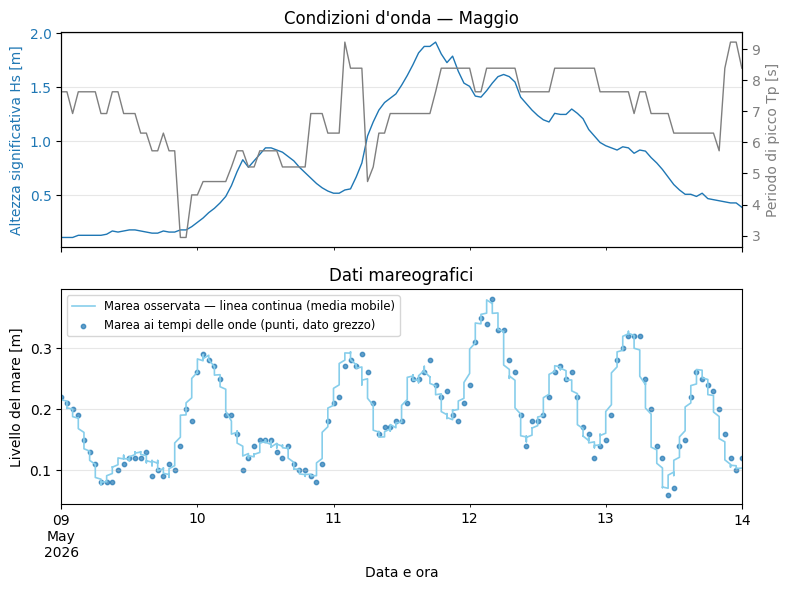

📊 Grafico salvato in: /content/drive/MyDrive/Wave_Runup/Risultati/waves_tides_plot_Maggio.png


In [21]:
# --- 📈 Visualizzazione combinata: linea di marea completa + punti ai tempi delle onde ---

waves_tides_plot = waves_tides.set_index('time') if 'time' in waves_tides.columns else waves_tides
tides_line = tides_df.sort_index()          # linea continua (serie completa)
waves_points = waves_tides_plot.sort_index()  # punti ai tempi delle onde (post-merge)

# 🧴 Media mobile solo per la visualizzazione: rende la linea leggibile senza modificare
# i dati grezzi usati più avanti nel notebook (merge, calcolo del runup, ecc.)
plot_smoothing_window = "1h"   # es. "1h", "30min"; None per disattivare
if plot_smoothing_window:
    tides_line_plot = tides_line['WaterLevel'].rolling(plot_smoothing_window, center=True, min_periods=1).mean()
else:
    tides_line_plot = tides_line['WaterLevel']

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# === Pannello superiore: Onde ===
ax1 = axs[0]
ax2 = ax1.twinx()

waves_points['Hs'].plot(ax=ax1, color='tab:blue', lw=1)
ax1.set_ylabel('Altezza significativa Hs [m]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

waves_points['Tmean'].plot(ax=ax2, color='tab:gray', lw=1)
ax2.set_ylabel('Periodo di picco Tp [s]', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

ax1.set_title(f"Condizioni d'onda — {event_name}")

# === Pannello inferiore: Maree ===
tides_line_plot.plot(ax=axs[1], color='skyblue', lw=1.2, label='Marea osservata — linea continua (media mobile)')

axs[1].scatter(
    waves_points.index,
    waves_points['WaterLevel'],
    s=10,
    alpha=0.7,
    label='Marea ai tempi delle onde (punti, dato grezzo)'
)

axs[1].set_ylabel('Livello del mare [m]')
axs[1].set_xlabel('Data e ora')
axs[1].set_title('Dati mareografici')
axs[1].legend(fontsize='small')

for ax in axs:
    ax.grid(True, alpha=0.3)
plt.tight_layout()

output_path = os.path.join(results_dir, f"waves_tides_plot_{event_name}.png")
fig.savefig(output_path, dpi=300)
plt.show()

print(f"📊 Grafico salvato in: {output_path}")

## 💾 Esportazione del dataset combinato onde–maree

A questo punto, esportiamo il **dataset unito** `waves_tides` in formato **CSV** nella cartella `Risultati`.

---

### 📂 Contenuto del file
Il file salvato si chiama: `waves_tides_merged_<event_name>.csv`

e contiene, per ogni istante temporale, le variabili principali già allineate:

- `Hs` → altezza significativa dell'onda (m)
- `Tmean` → periodo di picco dell'onda, Tp (s)
- `WaterLevel` → livello del mare (m)
- `time_diff` → differenza temporale tra la misura d'onda e quella di marea (in minuti)

---

### 🧭 Come usare il file
Puoi trovare il file nella sottocartella `Risultati/`. Da qui puoi:
- aprirlo in **Excel**, **LibreOffice** o **QGIS** per visualizzare e analizzare i dati;
- ricaricarlo in Python con `pd.read_csv()`;
- allegarlo alla relazione tecnica finale.

In [22]:
# --- 💾 Esportazione del dataset combinato onde + maree nella cartella "Risultati" ---

output_filename = f"waves_tides_merged_{event_name}.csv"
output_path = os.path.join(results_dir, output_filename)

waves_tides.to_csv(output_path, index=True, sep=';', float_format='%.3f')

print(f"✅ File esportato correttamente in:\n{output_path}")

pd.read_csv(output_path, sep=';').head()

✅ File esportato correttamente in:
/content/drive/MyDrive/Wave_Runup/Risultati/waves_tides_merged_Maggio.csv


,Unnamed: 0,time,Hs,Tmean,Dir,dates,DATE,TIME,HYDROMETRIC LEVEL,WaterLevel,time_diff
0,0,2026-05-09 00:00:00,0.11,7.63,165.32,2026-05-09 00:00:00,2026-05-09,00:00,"0,223",0.22,0.0
1,1,2026-05-09 01:00:00,0.11,7.63,163.19,2026-05-09 01:00:00,2026-05-09,01:00,"0,206",0.21,0.0
2,2,2026-05-09 02:00:00,0.11,6.93,158.68,2026-05-09 02:00:00,2026-05-09,02:00,"0,197",0.20,0.0
3,3,2026-05-09 03:00:00,0.13,7.63,157.14,2026-05-09 03:00:00,2026-05-09,03:00,"0,192",0.19,0.0
4,4,2026-05-09 04:00:00,0.13,7.63,158.22,2026-05-09 04:00:00,2026-05-09,04:00,"0,15",0.15,0.0


## 🏖️ Inserimento delle pendenze di spiaggia (tanβ) + salvataggio e istogrammi

I modelli di runup richiedono, per **ogni singola osservazione onda-marea**, un valore di pendenza della spiaggia (*tanβ*). In questa sezione inserite una o più misure di tanβ, e il notebook costruisce da queste una **serie di pendenze** lunga quanto `waves_tides` (una pendenza per ogni riga), da usare nel calcolo del runup.

### 🎲 Perché una *serie* di pendenze e non un solo numero fisso?
La pendenza reale di una spiaggia **non è mai perfettamente costante**: varia lungo la costa, in funzione della morfologia locale. Se assegnassimo lo stesso valore fisso a tutte le osservazioni, la variabilità del runup calcolato rifletterebbe solo le condizioni di onda e marea, ignorando l'incertezza legata alla pendenza. Per questo la useremo diversamente a seconda di quanti valori inserite:

- **Se inserite 1 solo valore:** non c'è alcun modo statistico di stimare una variabilità da un singolo dato. Il notebook usa quindi **quel valore come costante** per tutte le osservazioni: nessuna variabilità di pendenza viene introdotta, e le differenze tra i risultati di runup dipenderanno solo da onde e marea. È una scelta semplice, onesta e adatta se avete una sola misura rappresentativa del sito.
- **Se inserite 2 o più valori:** il notebook calcola **media e deviazione standard** delle vostre misure e genera una serie casuale (di lunghezza pari a `waves_tides`) campionata da una distribuzione normale con quella media e deviazione standard. In questo modo la variabilità naturale della pendenza che avete osservato sul campo viene propagata nel calcolo del runup.

Il notebook ti chiede prima **quanti valori vuoi inserire** (minimo 1): se ne hai misurati diversi lungo la spiaggia, inseriscili tutti — più valori fornite, più realistica sarà la stima della variabilità.

I valori inseriti verranno salvati in: `Risultati/beach_slopes_input_<event_name>.csv`

e verrà prodotto un istogramma dei valori inseriti; se avete inserito 2 o più valori, viene prodotto anche un secondo istogramma della serie campionata, nella stessa cartella.

---

### 📘 Che cos'è la pendenza della spiaggia (tanβ)
La pendenza della spiaggia è, in prima approssimazione, il **rapporto tra dislivello e distanza orizzontale** nel tratto emerso interessato dal runup (la *foreshore*):
$$
\tan \beta = \frac{\Delta z}{\Delta x}
$$
- Esempi:
  - *tanβ* = 0.05 → 5 cm di dislivello ogni 1 m in orizzontale (≈ 2.86°)
  - *tanβ* = 0.10 → 10 cm/m (≈ 5.71°)

> 🔁 **Conversioni utili**
> - Da **gradi** a *tanβ*: `tanβ = tan(θ in radianti)`
> - Da **% pendenza** a *tanβ*: `tanβ = pendenza_% / 100`

**Ordini di grandezza tipici** (possono variare molto!):
- spiagge sabbiose poco inclinate: *tanβ* ≈ 0.01–0.05
- spiagge più ripide/ghiaiose: *tanβ* ≈ 0.05–0.15

---

### 🛰️ Come ricavare *tanβ* da un DEM in **QGIS**
Avrai un **Digital Elevation Model** (DEM) e un **video tutorial** dedicato. Ecco due approcci comuni:

1. **Profilo topografico perpendicolare alla costa**
   - Traccia una linea dalla battigia verso terra (perpendicolare alla costa).
   - Estrai il profilo di quota (Tool: *Profile Tool* o *Sample raster values*).
   - Seleziona un tratto **foreshore** rappresentativo (es. tra MSL e berm crest) e calcola \(\Delta z / \Delta x\) (fit lineare o differenza tra estremi).
   - Ripeti in più punti lungo la spiaggia → otterrai una piccola **collezione di *tanβ***.

2. **Mappa di pendenza (Slope)**
   - Calcola la **pendenza** del DEM (Raster → Terrain analysis → *Slope*).
   - Otterrai pendenza in **gradi** o in **%**.
   - Converti a *tanβ* con le formule di cui sopra e campiona valori nella **fascia foreshore** (evita dune o retrospiaggia).

> ✅ **Consigli pratici**
> - Usa una **finestra di misura coerente** con la scala del runup (qualche decina di metri).
> - Evita zone **alterate** (strutture rigide, canali, corpi detritici effimeri).
> - Fai più misure lungo costa e **annota outlier**.

In [28]:
# --- 🏖️ Input delle pendenze, salvataggio CSV e istogrammi nella cartella "Risultati" ---

# Assicuriamoci che la cartella Risultati esista
os.makedirs(results_dir, exist_ok=True)

# 0️⃣ Chiedi quante pendenze si vogliono inserire (minimo 1)
n_slopes = None
while n_slopes is None:
    raw_n = input("Quanti valori di pendenza (tanβ) vuoi inserire? (minimo 1): ").strip()
    try:
        val_n = int(raw_n)
        if val_n < 1:
            print("⚠️  Devi inserire almeno 1 valore. Riprova.")
            continue
        n_slopes = val_n
    except ValueError:
        print("⚠️  Valore non valido. Inserisci un numero intero (es. 5).")

# 1️⃣ Raccogli le pendenze dall'utente (una per volta)
user_slopes = []
print(f"Inserisci {n_slopes} valori di pendenza della spiaggia (tanβ). Esempio: 0.04")
for i in range(1, n_slopes + 1):
    while True:
        raw = input(f"Pendenza {i}/{n_slopes}: ").strip().replace(",", ".")
        try:
            val = float(raw)
            if val <= 0:
                print("⚠️  La pendenza deve essere positiva. Riprova.")
                continue
            user_slopes.append(val)
            break
        except ValueError:
            print("⚠️  Valore non valido. Inserisci un numero (es. 0.045).")

# 2️⃣ Salva SOLO le pendenze inserite in CSV
inputs_df = pd.DataFrame({"slope_input": user_slopes}, index=range(1, n_slopes + 1))
input_csv_path = os.path.join(results_dir, f"beach_slopes_input_{event_name}.csv")
inputs_df.to_csv(input_csv_path, sep=";", float_format="%.5f")
print(f"✅ Pendenze inserite salvate in: {input_csv_path}")


# 3️⃣ Costruisci la serie di pendenze da associare a ciascuna osservazione onda-marea.
#
#    - Con 1 solo valore: nessuna variabilità statistica può essere stimata da un unico dato,
#      quindi la pendenza è COSTANTE per tutte le osservazioni (nessuna variabilità inventata).
#    - Con 2 o più valori: la serie è campionata da una distribuzione normale con media e
#      deviazione standard calcolate sui valori misurati, per rappresentare la variabilità
#      naturale della pendenza lungo la spiaggia.
rng = np.random.default_rng()  # seed non fissato: qui serve solo a campionare i valori misurati

def generate_slope_series(slope_list, length, rng):
    if len(slope_list) == 1:
        # Un solo dato disponibile: usiamo un valore costante, senza inventare variabilità.
        return np.full(length, slope_list[0])

    mean_slope = float(np.mean(slope_list))
    std_slope = float(np.std(slope_list))
    while True:
        slopes = rng.normal(loc=mean_slope, scale=std_slope, size=length)
        if np.all(slopes > 0):
            return slopes

slope_series = generate_slope_series(user_slopes, len(waves_tides), rng)

# Aggiungi la serie al DataFrame unito
waves_tides["slope"] = slope_series

if n_slopes == 1:
    print(f"ℹ️ Un solo valore inserito (tanβ = {user_slopes[0]:.4f}): la pendenza è COSTANTE per tutto l'evento.")
else:
    print(
        f"ℹ️ {n_slopes} valori inseriti: pendenza campionata da una distribuzione normale "
        f"(media={np.mean(user_slopes):.4f}, deviazione standard={np.std(user_slopes):.4f})."
    )

# 4️⃣ Istogramma della serie campionata: con un solo valore inserito è costante per costruzione
#    (un'unica barra), quindi lo mostriamo solo quando ha senso, cioè con 2+ valori.
sampled_hist_path = None
if n_slopes >= 2:
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.hist(slope_series, bins=30, edgecolor="black", color="lightgreen")
    ax2.set_title("Distribuzione pendenze campionate (serie completa)")
    ax2.set_xlabel("Pendenza (tanβ)")
    ax2.set_ylabel("Frequenza")
    ax2.grid(True, alpha=0.3)

    sampled_hist_path = os.path.join(results_dir, f"hist_pendenze_campionate_{event_name}.png")
    fig2.savefig(sampled_hist_path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("ℹ️ Nessun istogramma della serie campionata: con un solo valore la pendenza è costante.")

print("✅ Serie 'slope' aggiunta a waves_tides.")
msg = f"📊 Istogrammi salvati in:\n- {input_hist_path}"
if sampled_hist_path:
    msg += f"\n- {sampled_hist_path}"
print(msg)

Quanti valori di pendenza (tanβ) vuoi inserire? (minimo 1): 1
Inserisci 1 valori di pendenza della spiaggia (tanβ). Esempio: 0.04
Pendenza 1/1: 0.06
✅ Pendenze inserite salvate in: /content/drive/MyDrive/Wave_Runup/Risultati/beach_slopes_input_Maggio.csv
ℹ️ Un solo valore inserito (tanβ = 0.0600): la pendenza è COSTANTE per tutto l'evento.
ℹ️ Nessun istogramma della serie campionata: con un solo valore la pendenza è costante.
✅ Serie 'slope' aggiunta a waves_tides.
📊 Istogrammi salvati in:
- /content/drive/MyDrive/Wave_Runup/Risultati/hist_pendenze_inserite_Maggio.png


## 🌊 Calcolo del *Wave Runup* con modelli empirici

### 🔍 Che cos'è il *wave runup*?

Il **wave runup** è la massima estensione verticale raggiunta dalle onde quando si infrangono e risalgono sulla spiaggia.
È controllato principalmente da tre fattori:

- **Altezza e periodo dell'onda**
- **Pendenza della spiaggia**
- **Livello di marea**

Il *runup* è una variabile fondamentale negli studi costieri, perché consente di stimare il rischio di **allagamento** e **erosione** costiera — specialmente se considerato insieme all'**innalzamento del livello del mare** (*sea level rise*).

<div style="text-align: center">
    <img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-017-01362-7/MediaObjects/41598_2017_1362_Fig1_HTML.jpg?as=webp" width="600">
    <br>
    <small><b>Figura:</b> Componenti del *wave runup*. Fonte: Vitousek et al. (2017), <i>Scientific Reports</i>.
    <a href="https://doi.org/10.1038/s41598-017-01362-7" target="_blank">https://doi.org/10.1038/s41598-017-01362-7</a></small>
</div>

---

### 🧩 Cosa significa "modello empirico"?

Un **modello empirico** è una formula o relazione matematica che si basa su **osservazioni e misure sperimentali**, più che su una teoria fisica completa.
In pratica, i ricercatori raccolgono **dati reali** (ad esempio misure di onde, maree e runup su diverse spiagge) e cercano di identificare **correlazioni** tra le variabili principali.

Nel caso del *wave runup*, un modello empirico tipicamente esprime una relazione del tipo:

$$
R_2 = f(H_s, T_p, \tan\beta)
$$

dove:
- \( R_2 \) è il runup al 2% di superamento (quota raggiunta solo dalle onde più energetiche),
- \( H_s \) è l'altezza significativa dell'onda,
- \( T_p \) è il periodo di picco dell'onda,
- \( \tan\beta \) è la pendenza della spiaggia.

🔹 **Vantaggi:**
- sono **veloci da applicare** e richiedono poche variabili;
- permettono di stimare il runup in assenza di misure dirette.

🔸 **Limiti:**
- derivano da **condizioni sperimentali specifiche**, per cui possono funzionare meglio solo su spiagge simili a quelle di calibrazione;
- non descrivono i processi fisici nel dettaglio, ma ne **riassumono il comportamento medio**.

> 💡 In sintesi: i modelli empirici sono strumenti pratici, nati da dati reali, che semplificano la complessità fisica per fornire stime rapide e utili del runup.

---

### 🧠 Cosa stiamo facendo in questo passaggio

In questa fase applichiamo **diversi modelli empirici pubblicati in letteratura** per stimare il livello di *runup* al **2% di superamento** (*R2*), per l'evento definito in precedenza.

Ogni modello utilizza come input:
- **Hs** → altezza significativa dell'onda
- **Tp** (colonna `Tmean`) → periodo di picco dell'onda
- **β** → pendenza della spiaggia (*tanβ*)
- **Livello di marea** → sommato a R2 per ottenere l'**altezza totale dell'acqua** in battigia (*Total Water Level*)

I modelli implementati sono:
- Stockdon et al. (2006)
- Vousdoukas et al. (2012)
- Holman (1986)
- Nielsen (2009)
- Ruggiero et al. (2001)
- Atkinson et al. (2017)
- Senechal et al. (2011)
- Passarella et al. (2018)

Il risultato è un nuovo **DataFrame** con il *runup* stimato da ciascun modello, più una colonna con la **media d'ensemble**.

---

### 📦 Sul pacchetto `py-wave-runup`

Tutti questi modelli sono implementati nella libreria open-source
[`py-wave-runup`](https://py-wave-runup.readthedocs.io/en/latest/?badge=latest), sviluppata da **Chris Leaman**.

### 🧾 Citazioni e buone pratiche

⚠️ **È indispensabile citare correttamente i modelli di runup utilizzati.** Troverai tutte le **citazioni complete** nella documentazione del pacchetto *py-wave-runup*. Nel corso ti verrà fornito un **tutorial dedicato su Zotero**.

📤 Alla fine del calcolo, i risultati di tutti i modelli vengono salvati in un file CSV nella cartella `Risultati/`.

In [29]:
# === 🧮 Calcolo del runup con più modelli + export in Risultati ===

Hs   = pd.to_numeric(waves_tides['Hs'], errors='coerce').values
Tp   = pd.to_numeric(waves_tides['Tmean'], errors='coerce').values
tide = pd.to_numeric(waves_tides['WaterLevel'], errors='coerce').values
beta = pd.to_numeric(waves_tides['slope'], errors='coerce').values

time_index = pd.to_datetime(waves_tides['time'], errors='coerce') if 'time' in waves_tides.columns else None

mask_valid = np.isfinite(Hs) & np.isfinite(Tp) & np.isfinite(tide) & np.isfinite(beta)
if not mask_valid.all():
    Hs, Tp, tide, beta = Hs[mask_valid], Tp[mask_valid], tide[mask_valid], beta[mask_valid]
    if time_index is not None:
        time_index = pd.to_datetime(time_index[mask_valid])

runup_dict = {
    'Stockdon et al. (2006)':   (models.Stockdon2006(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Vousdoukas et al. (2012)': (models.Vousdoukas2012(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Holman (1986)':            (models.Holman1986(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Nielsen (2009)':           (models.Nielsen2009(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Ruggiero et al. (2001)':   (models.Ruggiero2001(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Atkinson et al. (2017)':   (models.Atkinson2017(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Senechal et al. (2011)':   (models.Senechal2011(Hs=Hs, Tp=Tp, beta=beta)).R2 + tide,
    'Passarella et al. (2018)': (models.Passarella2018(Hs=Hs, Tp=Tp, beta=beta)).swash + tide
}

R2 = pd.DataFrame(runup_dict)

R2['Hs']         = Hs
R2['Tmean']      = Tp
R2['WaterLevel'] = tide
R2['slope']      = beta

if time_index is not None:
    R2.insert(0, 'time', time_index)

runup_cols = [
    'Stockdon et al. (2006)',
    'Vousdoukas et al. (2012)',
    'Holman (1986)',
    'Nielsen (2009)',
    'Ruggiero et al. (2001)',
    'Atkinson et al. (2017)',
    'Senechal et al. (2011)',
    'Passarella et al. (2018)'
]
R2['Runup_ensemble_mean'] = R2[runup_cols].mean(axis=1)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
outfile = os.path.join(results_dir, f"runup_results_{event_name}_{timestamp}.csv")
R2.to_csv(outfile, index=False)

print(f"✅ Runup calcolato con {len(runup_cols)} modelli per l'evento '{event_name}'.")
print(f"💾 File esportato in: {outfile}")

✅ Runup calcolato con 8 modelli per l'evento 'Maggio'.
💾 File esportato in: /content/drive/MyDrive/Wave_Runup/Risultati/runup_results_Maggio_20260721_162622.csv


## 📊 Confronto tra i modelli empirici di *wave runup*

In questa sezione visualizziamo i risultati del calcolo del *runup* attraverso una serie di **istogrammi comparativi**.
Ogni istogramma mostra la distribuzione dei valori di *runup* stimati da uno dei modelli empirici utilizzati.

---

### 🧩 Cosa rappresentano gli istogrammi
- Ogni pannello mostra la **frequenza dei valori di runup** (asse Y) per intervalli di ampiezza **0.2 m** (bin fissi).
- Tutti gli istogrammi condividono la **stessa scala** sugli assi X e Y, così da poter confrontare visivamente le distribuzioni.
- L'ultimo pannello mostra **tutti i modelli combinati**.

---

### 🔍 Come interpretare i grafici
- La **posizione del picco** indica il valore di runup più frequente stimato dal modello.
- La **larghezza della distribuzione** riflette la variabilità del modello rispetto alle condizioni di onda e marea.

> 💡 *Esempio di lettura:* Se un modello mostra una distribuzione più spostata verso destra (runup più alti), significa che tende a **sovrastimare** le condizioni di runup massimo rispetto ad altri.

---

### 📦 Risultato esportato
L'intera figura viene salvata automaticamente nella cartella `Risultati/`.

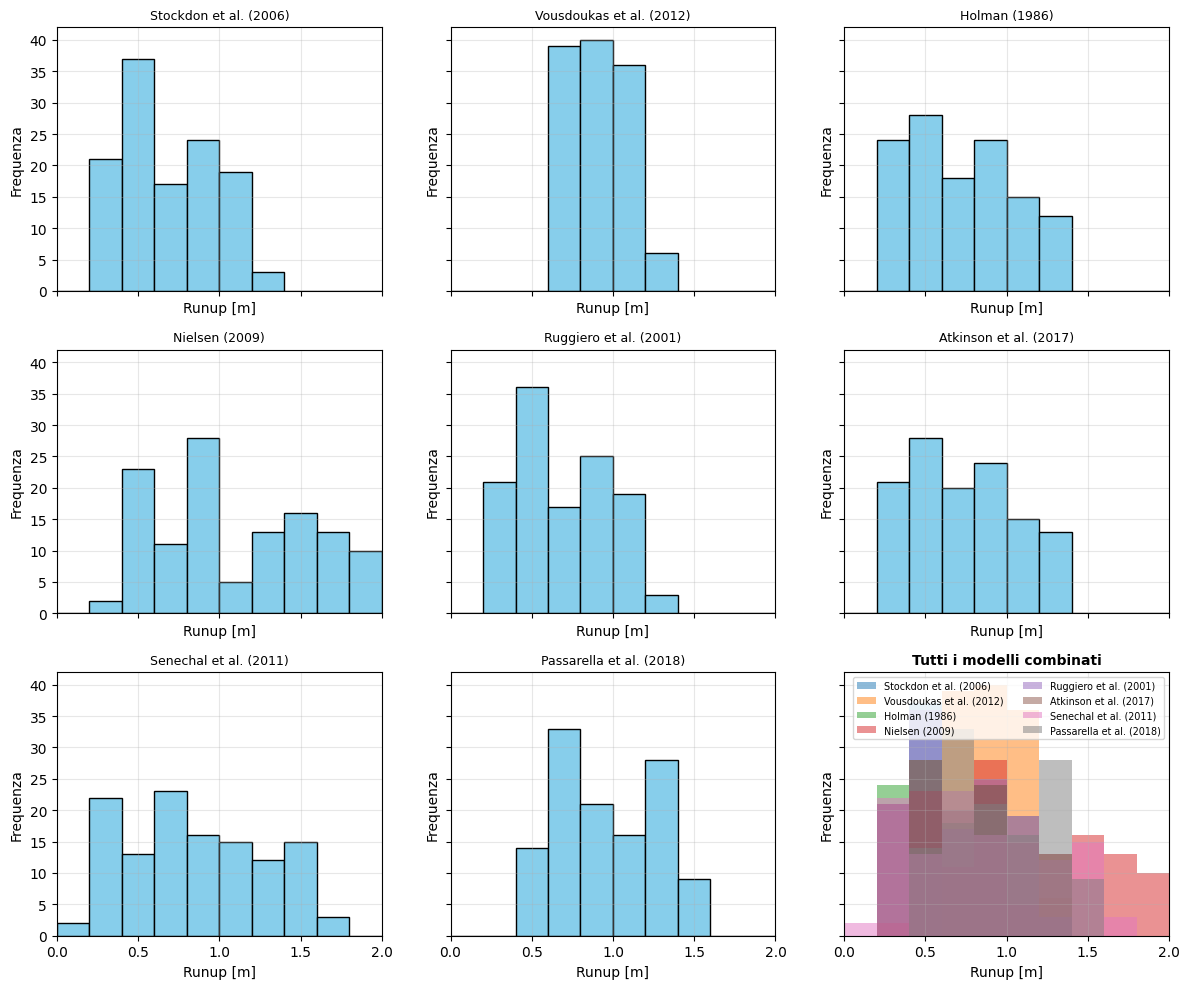

✅ Istogrammi salvati in: /content/drive/MyDrive/Wave_Runup/Risultati/runup_histograms_all_models_Maggio.png


In [30]:
# --- 📊 Istogrammi comparativi dei risultati di runup per ciascun modello empirico ---

n_models = len(runup_cols)
n_rows, n_cols = 3, 3  # 8 modelli + 1 combinato

all_values = np.concatenate([R2[col].dropna().values for col in runup_cols])
xmin, xmax = np.floor(all_values.min()), np.ceil(all_values.max())
bin_width = 0.2
bins = np.arange(xmin, xmax + bin_width, bin_width)

fig, axs = plt.subplots(
    n_rows, n_cols,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)
axs = axs.flatten()

for i, col in enumerate(runup_cols):
    axs[i].hist(R2[col], bins=bins, color='skyblue', edgecolor='black')
    axs[i].set_title(col, fontsize=9)
    axs[i].set_xlabel('Runup [m]')
    axs[i].set_ylabel('Frequenza')
    axs[i].grid(True, alpha=0.3)
    axs[i].set_xlim(xmin, xmax)

combined_ax = axs[min(n_models, len(axs)-1)]
for col in runup_cols:
    combined_ax.hist(R2[col], bins=bins, alpha=0.5, label=col)
combined_ax.set_title('Tutti i modelli combinati', fontsize=10, fontweight='bold')
combined_ax.set_xlabel('Runup [m]')
combined_ax.set_ylabel('Frequenza')
combined_ax.legend(fontsize='x-small', loc='upper right', ncol=2)
combined_ax.grid(True, alpha=0.3)
combined_ax.set_xlim(xmin, xmax)

if len(axs) > n_models + 1:
    for ax in axs[n_models + 1:]:
        ax.axis('off')

plt.tight_layout()
hist_output_path = os.path.join(results_dir, f"runup_histograms_all_models_{event_name}.png")
fig.savefig(hist_output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✅ Istogrammi salvati in: {hist_output_path}")

## 📈 Analisi ensemble dei modelli di *wave runup*

Dopo aver calcolato il runup con diversi modelli empirici, possiamo combinarne i risultati per ottenere una **visione d'insieme** del comportamento stimato.
Questo approccio è detto **analisi ensemble**.

---

### 🧩 Che cos'è un *ensemble* di modelli
Un **ensemble** è un insieme di più modelli che stimano la stessa variabile (in questo caso, il *runup*). L'idea è che ogni modello rappresenti una prospettiva diversa — basata su spiagge, dati o approcci sperimentali differenti — e che la loro combinazione fornisca una stima **più robusta e meno dipendente** da un singolo metodo.

---

### 📊 Cosa mostra il grafico
- 🔵 **Banda azzurra (5°–95° percentile)** → intervallo di incertezza tra i modelli.
- ⚫ **Linea blu (50° percentile)** → mediana dell'ensemble.
- 🔴 **Linea rossa tratteggiata (media ensemble)** → media dei valori restituiti dai modelli.

### 🧠 Come interpretare
- Se la **banda azzurra è stretta**, i modelli sono coerenti → alta affidabilità.
- Se la **banda è ampia**, i modelli divergono → incertezza maggiore.

### 📦 Output
Il grafico viene salvato automaticamente in `Risultati/`.

In [ ]:
# --- 📈 Analisi statistica dell'ensemble di modelli di runup ---

ensemble = R2[runup_cols]

runup_mean = ensemble.mean(axis=1)
runup_p05  = ensemble.quantile(0.05, axis=1)
runup_p50  = ensemble.quantile(0.50, axis=1)
runup_p95  = ensemble.quantile(0.95, axis=1)

R2["Runup_ensemble_mean"] = runup_mean
R2["Runup_p05"] = runup_p05
R2["Runup_p50"] = runup_p50
R2["Runup_p95"] = runup_p95

# Asse temporale: usiamo la colonna 'time' (data e ora), non il semplice indice numerico
x = R2["time"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(
    x,
    R2["Runup_p05"],
    R2["Runup_p95"],
    color="skyblue",
    alpha=0.3,
    label="Intervallo 5°–95° percentile"
)

ax.plot(x, R2["Runup_p50"], color="blue", lw=1.5, label="Mediana (50° percentile)")
ax.plot(x, R2["Runup_ensemble_mean"], color="darkred", lw=1.2, linestyle="--", label="Media ensemble")

ax.set_title(f"Distribuzione temporale del runup – Ensemble dei modelli ({event_name})", fontsize=12)
ax.set_xlabel("Data e ora")
ax.set_ylabel("Runup totale [m]")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()  # ruota le etichette delle date per renderle leggibili
plt.tight_layout()

summary_plot_path = os.path.join(results_dir, f"runup_ensemble_statistics_{event_name}.png")
fig.savefig(summary_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("✅ Analisi ensemble completata.")
print(f"📊 Figura salvata in: {summary_plot_path}")

## 🗺️ Dalla modellazione al GIS: scelta dei valori di *runup* da mappare

Dopo aver stimato il *wave runup* con diversi modelli empirici, possiamo passare alla fase successiva dell'esercitazione:
**rappresentare il runup su una mappa costiera** per individuare le aree potenzialmente inondate durante la mareggiata.

---

### 🎯 Obiettivo
Identificare uno o più **valori rappresentativi di runup** (*R₂*, media ensemble o percentili) da riportare in ambiente GIS, per stimare:
- la **massima estensione dell'inondazione** costiera;
- le **aree più vulnerabili** lungo la spiaggia e nella retrospiaggia;
- eventuali **interazioni con dune, infrastrutture o aree antropizzate**.

---

### 🧩 Come scegliere il valore di *runup* da mappare
1. **Scegliete la metrica più adatta allo scenario di interesse:**
   - per un **evento medio–energetico**, usate la **mediana (50° percentile)** o la **media ensemble**;
   - per uno **scenario estremo**, usate il **95° percentile** o il valore massimo tra i modelli;
   - se volete mostrare la **variabilità tra modelli**, potete esportare più soglie (es. media, 50° e 95° percentile) come "fasce di probabilità" di inondazione.
2. **Motivate la vostra scelta** nella relazione tecnica.

---

### 🗂️ Passaggio successivo: uso dei risultati in QGIS
Una volta scelto il valore di *runup* da mappare, lo userete in **QGIS** per identificare le aree inondate sul **Digital Elevation Model (DEM)** e sull'**ortofoto** della zona di studio.

> 📚 Le istruzioni pratiche per questa fase — inclusi i passaggi su QGIS e la redazione della relazione tecnica — saranno fornite in **tutorial dedicati**.

---

### 📄 Relazione tecnica finale

L'output richiesto di questa esercitazione è una **relazione tecnica sintetica** (massimo **5 pagine**, inclusa la bibliografia) che riassuma:

1. L'**evento** modellizzato, come è stato individuato a partire dalla serie storica esplorata, le fonti dei dati (mareografico.it, Copernicus Marine) e le principali elaborazioni svolte nel notebook.
2. I **modelli di runup** applicati e le **citazioni** corrispondenti (da inserire con Zotero).
3. I **valori di runup** selezionati per la mappatura in QGIS e la motivazione della scelta.
4. Le **mappe di inondazione** prodotte in QGIS e la loro interpretazione.
5. Una breve **discussione critica** sui risultati e sulle fonti di incertezza.

> ✍️ *Obiettivo didattico:* dimostrare la capacità di collegare **dati osservati**, **modellazione numerica** e **analisi spaziale in GIS**, per interpretare un evento reale di mareggiata e inondazione costiera.

---

## 📝 Acknowledgments

This script was developed by **Alessio Rovere** at **Ca' Foscari University of Venice**, with the support of **ChatGPT/Claude** for code structuring, optimization, and documentation refinement.

Tide-gauge data courtesy of ISPRA's **Rete Mareografica Nazionale / Rete Ondametrica Nazionale** ([mareografico.it](https://www.mareografico.it)). Wave data courtesy of the **Copernicus Marine Service** (E.U. Copernicus Marine Environment Monitoring Service, products `MEDSEA_MULTIYEAR_WAV_006_012` and/or `MEDSEA_ANALYSISFORECAST_WAV_006_017`).

⚠️ **Disclaimer:**
The code is provided *as is*, without any warranties or guarantees of correctness. Users are responsible for verifying results and adapting the scripts to their specific needs. Neither the authors nor the European Union can be held responsible for any use that may be made of the information or code contained herein.